# **Importing Libraries**

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression


# **Data Loading**

In [263]:
df=pd.read_csv(r"/content/data (1).csv")
df.head(10)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
6,2014-05-02 00:00:00,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,2616 174th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA
8,2014-05-02 00:00:00,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,1985,0,46611-46625 SE 129th St,North Bend,WA 98045,USA
9,2014-05-02 00:00:00,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,1945,2010,6811 55th Ave NE,Seattle,WA 98115,USA


# **Data Understanding & Cleaning**

In [264]:
df.shape

(4600, 18)

In [265]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


**Handling Constant Columns and Redundant Features**

In [266]:
cols_to_check = ['country', 'waterfront']
for col in cols_to_check:
    unique_count = df[col].nunique()
    if unique_count <= 1:
        print(f"Dropping column '{col}': Only {unique_count} unique value found.")
        df.drop(columns=[col], inplace=True)
    else:
        print(f"Keeping column '{col}': {unique_count} unique values found.")

Dropping column 'country': Only 1 unique value found.
Keeping column 'waterfront': 2 unique values found.


**Handling Zero-Value Records and Data Integrity**

In [267]:
df = df[df['price'] > 0].reset_index(drop=True)

**Logarithmic Transformation for Skewed Features**

In [268]:
df['log_price'] = np.log1p(df['price'])
df['log_sqft_living'] = np.log1p(df['sqft_living'])
df['log_sqft_lot'] = np.log1p(df['sqft_lot'])

**Feature Engineering and Attribute Construction**

In [269]:
df['age'] = 2014 - df['yr_built']

In [270]:
df['renovated_flag'] = (df['yr_renovated'] > 0).astype(int)

In [271]:
df['total_sqft'] = df['sqft_above'] + df['sqft_basement']

In [272]:
df['luxury_score'] = df['waterfront'] + df['view'] + (df['bathrooms'] / (df['bedrooms'] + 0.001))

**Statistical Outlier Detection using IQR**

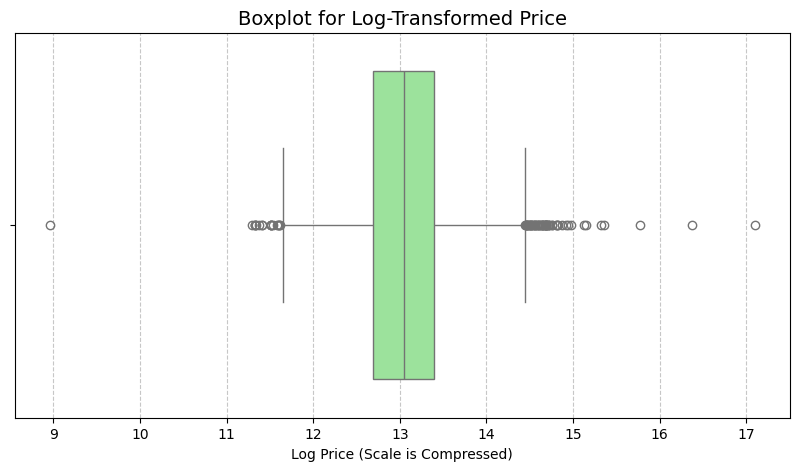

In [273]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['log_price'], color='lightgreen')

plt.title("Boxplot for Log-Transformed Price", fontsize=14)
plt.xlabel("Log Price (Scale is Compressed)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

*Domain-Driven Data Filtering and Validation*

In [274]:
results = pd.DataFrame(index=df.index)

results['domain_flag'] = (
    (df['price'] < 35000) |
    (df['sqft_living'] < 300) |
    (df['bedrooms'] > 12) |
    ((df['waterfront'] == 1) & (df['price'] < 650000)) |
    ((df['sqft_living'] > 8000) & (df['price'] < 1800000)) |
    (df['yr_renovated'] > 2015) |
    (df['yr_built'] > 2015)
)

*Split the data into Clean and Raw (based on your domain_flag)*

In [275]:
# Note: ~ inverse the boolean, so we take rows where flag is False (Not an outlier)
df_clean = df[~results['domain_flag']].copy()

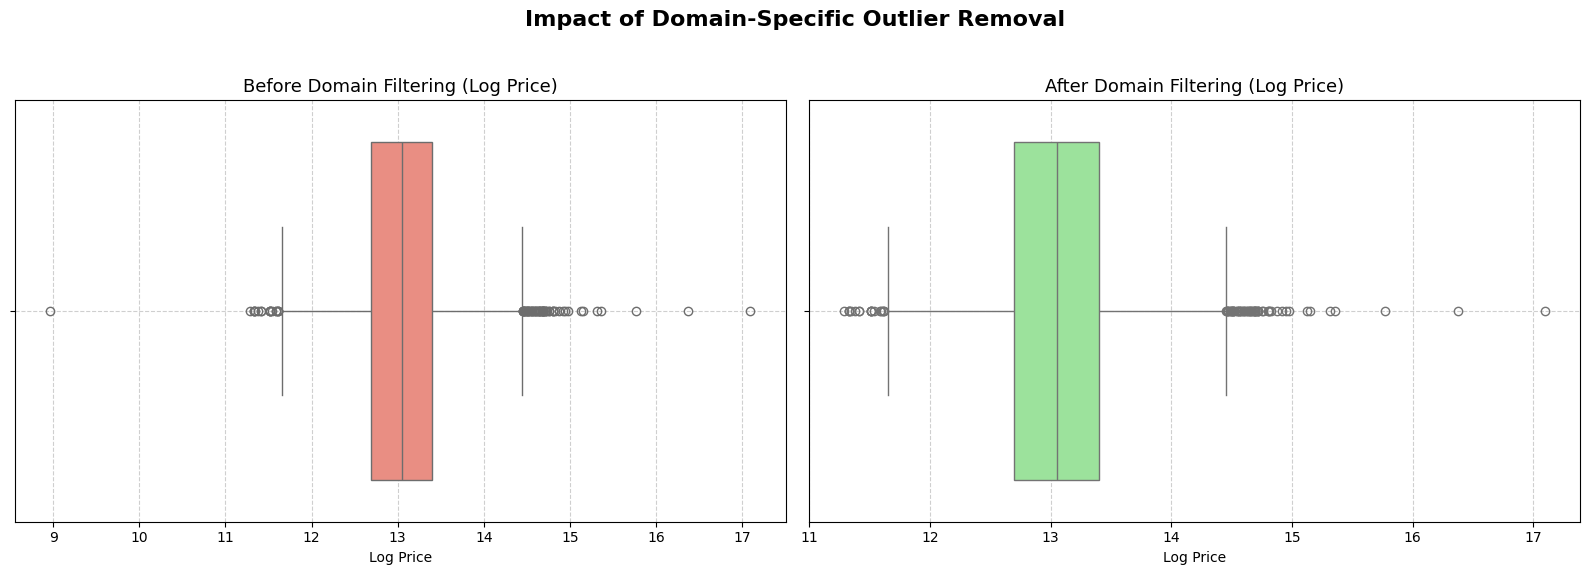

In [276]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
#Plot 1: Before Cleaning (Original Log Price)
sns.boxplot(x=df['log_price'], ax=axes[0], color='salmon')
axes[0].set_title("Before Domain Filtering (Log Price)", fontsize=13)
axes[0].set_xlabel("Log Price")
axes[0].grid(True, linestyle='--', alpha=0.6)
#Plot 2: After Cleaning (Clean Log Price)
sns.boxplot(x=df_clean['log_price'], ax=axes[1], color='lightgreen')
axes[1].set_title("After Domain Filtering (Log Price)", fontsize=13)
axes[1].set_xlabel("Log Price")
axes[1].grid(True, linestyle='--', alpha=0.6)
# Add a main title for the whole figure
plt.suptitle("Impact of Domain-Specific Outlier Removal", fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


***Print the impact summary***

In [277]:
print(f"Initial Records: {len(df)}")
print(f"Records Removed: {results['domain_flag'].sum()}")
print(f"Clean Records: {len(df_clean)}")

Initial Records: 4551
Records Removed: 8
Clean Records: 4543


In [278]:
df = df[~results['domain_flag']].reset_index(drop=True)

In [279]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower) & (df['price'] <= upper)]
df.head()


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,street,city,statezip,log_price,log_sqft_living,log_sqft_lot,age,renovated_flag,total_sqft,luxury_score
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,...,18810 Densmore Ave N,Shoreline,WA 98133,12.653962,7.201171,8.976262,59,1,1340,0.499833
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,...,26206-26214 143rd Ave SE,Kent,WA 98042,12.742569,7.565793,9.388319,48,0,1930,0.666445
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,...,857 170th Pl NE,Bellevue,WA 98008,12.948012,7.601402,8.991064,51,0,2000,0.749750
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,...,9105 170th Ave NE,Redmond,WA 98052,13.217675,7.570959,9.259226,38,1,1940,0.624844
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,...,522 NE 88th St,Seattle,WA 98115,13.102163,6.781058,8.761080,76,1,880,0.499750


*Make price_per_sqft exists*

In [280]:
df['price_per_sqft'] = df['price'] / df['sqft_living']

*Create bins (deciles) on sqft_living*

In [281]:
df['sqft_bin'] = pd.qcut(
    df['sqft_living'],
    q=10,
    labels=[f"Decile {i+1}" for i in range(10)],   # nicer labels
    duplicates='drop'
)

*Group and show*

In [282]:
print("Average price per sqft by living-area decile:")
print(
    df.groupby('sqft_bin', observed=True)[['sqft_living', 'price_per_sqft']]
      .mean()
      .round(1)
)

Average price per sqft by living-area decile:
           sqft_living  price_per_sqft
sqft_bin                              
Decile 1         913.3           335.7
Decile 2        1215.5           290.7
Decile 3        1435.1           266.7
Decile 4        1632.6           261.1
Decile 5        1828.3           236.1
Decile 6        2021.8           228.3
Decile 7        2249.4           236.8
Decile 8        2516.0           230.9
Decile 9        2861.7           224.2
Decile 10       3686.1           211.9


nicer table with more columns

In [283]:
print(
    df.groupby('sqft_bin', observed=True)
      .agg({
          'sqft_living': ['mean', 'min', 'max'],
          'price': ['mean', 'median'],
          'price_per_sqft': 'mean'
      })
      .round(1)
)

          sqft_living                 price           price_per_sqft
                 mean   min   max      mean    median           mean
sqft_bin                                                            
Decile 1        913.3   370  1090  301917.2  297000.0          335.7
Decile 2       1215.5  1092  1320  353466.8  345000.0          290.7
Decile 3       1435.1  1330  1530  382784.7  374725.0          266.7
Decile 4       1632.6  1540  1720  425992.5  405000.0          261.1
Decile 5       1828.3  1726  1920  431174.5  415000.0          236.1
Decile 6       2021.8  1930  2120  461707.8  445000.0          228.3
Decile 7       2249.4  2130  2370  532812.8  500162.0          236.8
Decile 8       2516.0  2375  2660  580970.4  585000.0          230.9
Decile 9       2861.7  2670  3120  641026.9  641500.0          224.2
Decile 10      3686.1  3130  7320  771865.4  792500.0          211.9


# **1. What is the relationship between living area (sqft_living) and sale price?**

Pearson correlation between sqft_living and price:

In [284]:
print(df[['sqft_living', 'price']].corr().iloc[0,1].round(4))

0.6321


Scatter + regression line

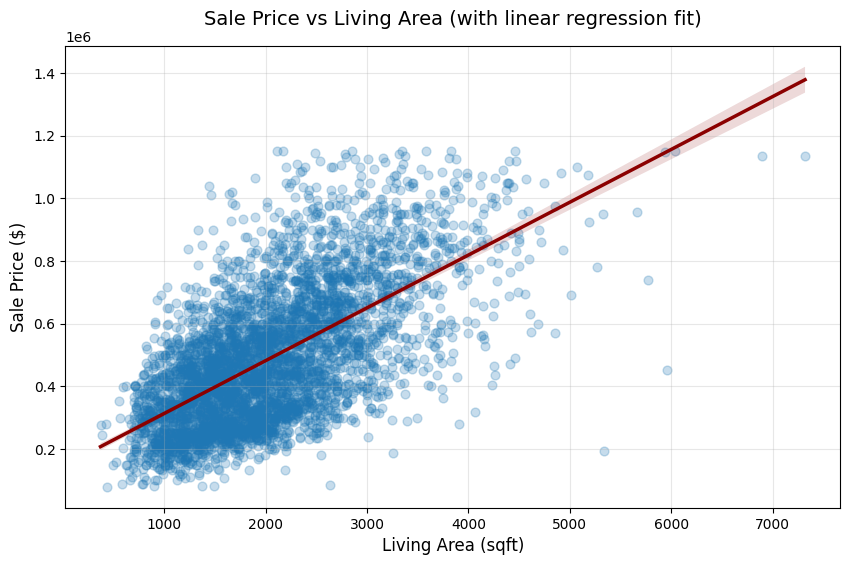

In [285]:
plt.figure(figsize=(10,6))
sns.regplot(x='sqft_living', y='price', data=df,
            scatter_kws={'alpha':0.25, 's':40},
            line_kws={'color':'darkred', 'lw':2.5})
plt.title("Sale Price vs Living Area (with linear regression fit)", fontsize=14, pad=15)
plt.xlabel("Living Area (sqft)", fontsize=12)
plt.ylabel("Sale Price ($)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

Price per sqft by living-area bins

In [286]:
df['sqft_bin'] = pd.qcut(df['sqft_living'], q=10, duplicates='drop')
print("\nAverage price per sqft by living-area decile:")
print(df.groupby('sqft_bin')[['sqft_living', 'price_per_sqft']].mean().round(1))


Average price per sqft by living-area decile:
                   sqft_living  price_per_sqft
sqft_bin                                      
(369.999, 1090.0]        913.3           335.7
(1090.0, 1320.0]        1215.5           290.7
(1320.0, 1530.0]        1435.1           266.7
(1530.0, 1720.0]        1632.6           261.1
(1720.0, 1920.0]        1828.3           236.1
(1920.0, 2120.0]        2021.8           228.3
(2120.0, 2370.0]        2249.4           236.8
(2370.0, 2660.0]        2516.0           230.9
(2660.0, 3120.0]        2861.7           224.2
(3120.0, 7320.0]        3686.1           211.9


# **2. Are waterfront homes significantly more expensive? How much more?**

Price statistics by waterfront status:

In [287]:
print(df.groupby('waterfront')['price'].agg(['count','mean','median','min','max']).round(0))

            count      mean    median       min        max
waterfront                                                
0            4294  486616.0  450000.0   80000.0  1150000.0
1               9  922667.0  950000.0  663000.0  1150000.0


Average price ratio (waterfront / non-waterfront):

In [288]:
ratio = df.groupby('waterfront')['price'].mean().iloc[1] / df.groupby('waterfront')['price'].mean().iloc[0]
print(f"Waterfront homes are {ratio:.2f}× more expensive on average")


Waterfront homes are 1.90× more expensive on average


Violin + strip plot (very informative)

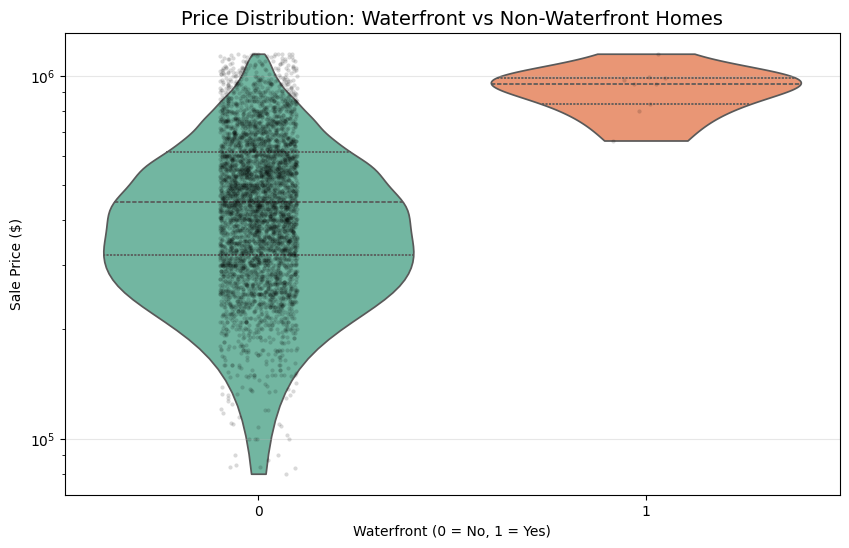

In [289]:
plt.figure(figsize=(10,6))
sns.violinplot(x='waterfront', y='price', data=df,
               palette='Set2', inner='quartile', cut=0)
sns.stripplot(x='waterfront', y='price', data=df, color='black', alpha=0.15, size=3)
plt.title("Price Distribution: Waterfront vs Non-Waterfront Homes", fontsize=14)
plt.xlabel("Waterfront (0 = No, 1 = Yes)")
plt.ylabel("Sale Price ($)")
plt.yscale('log')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# **3. How do number of bedrooms and bathrooms jointly affect price?**

Average price by bedroom count and bathroom categories (cells with ≥10 records):

In [290]:
bath_bins = pd.cut(df['bathrooms'], bins=[0,1,2,3,4,5,6,10], right=False)
pivot = df.pivot_table(
    values='price',
    index='bedrooms',
    columns=bath_bins,
    aggfunc='mean'
).round(0)

print(pivot)


bathrooms     [0, 1)    [1, 2)    [2, 3)    [3, 4)    [4, 5)     [5, 6)
bedrooms                                                               
0.0        1095000.0       NaN       NaN       NaN       NaN        NaN
1.0         271569.0  284050.0  286500.0       NaN       NaN        NaN
2.0         334034.0  359433.0  497216.0  500175.0       NaN        NaN
3.0         150000.0  385160.0  487260.0  588463.0  941000.0        NaN
4.0         142500.0  451022.0  556426.0  731694.0  839232.0  1042031.0
5.0              NaN  445579.0  563918.0  641917.0  917520.0   832500.0
6.0              NaN  515557.0  587748.0  660157.0  866667.0   397500.0
7.0              NaN       NaN  439500.0  412500.0  755600.0   540000.0
8.0              NaN       NaN  340000.0       NaN       NaN        NaN
9.0              NaN       NaN       NaN       NaN  599999.0        NaN


Heatmap

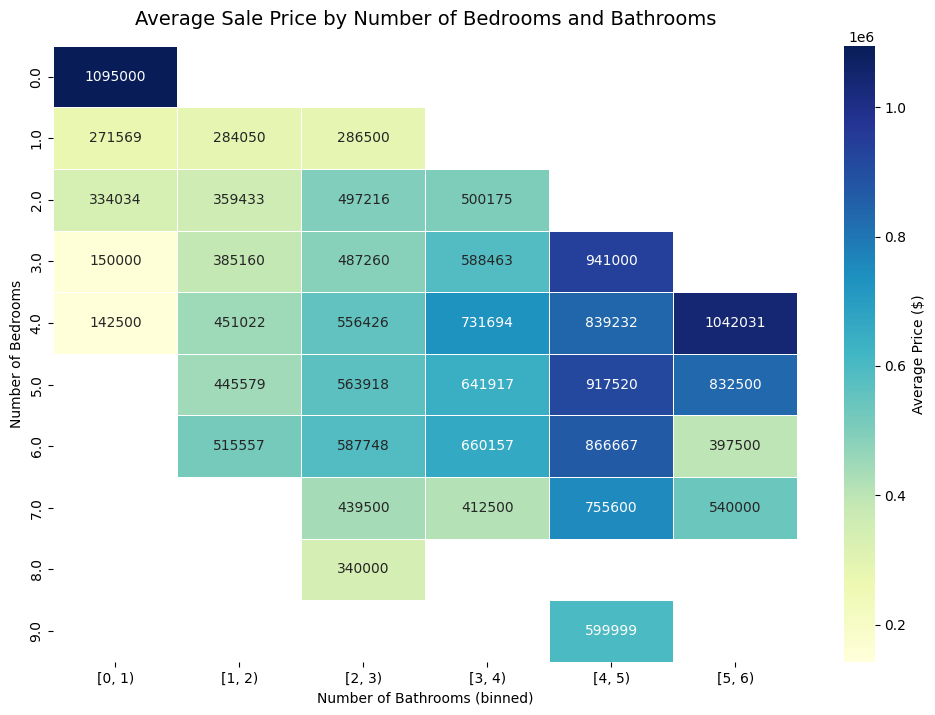

In [291]:
plt.figure(figsize=(12,8))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu",
            cbar_kws={'label': 'Average Price ($)'},
            linewidths=0.5)
plt.title("Average Sale Price by Number of Bedrooms and Bathrooms", fontsize=14, pad=15)
plt.xlabel("Number of Bathrooms (binned)")
plt.ylabel("Number of Bedrooms")
plt.show()

# **4. Do newer / renovated homes sell for more?**

In [292]:

print("Price statistics: Renovated vs Non-Renovated")
print(df.groupby('renovated_flag')['price'].agg(
    ['count','mean','median','min','max']
).round(0))

Price statistics: Renovated vs Non-Renovated
                count      mean    median      min        max
renovated_flag                                               
0                2555  500194.0  464000.0  80000.0  1150000.0
1                1748  469013.0  435000.0  84350.0  1150000.0


Age bins

In [293]:

df['age_bin'] = pd.qcut(df['age'], q=8, duplicates='drop')
print("\nAverage price by home age bin:")
print(df.groupby('age_bin')['price'].mean().round(0))


Average price by home age bin:
age_bin
(-0.001, 9.0]    529415.0
(9.0, 18.0]      551791.0
(18.0, 28.0]     515137.0
(28.0, 38.0]     464115.0
(38.0, 52.0]     423507.0
(52.0, 63.0]     440535.0
(63.0, 85.0]     440038.0
(85.0, 114.0]    538413.0
Name: price, dtype: float64


Boxen plot (better than regular box for skewed data)

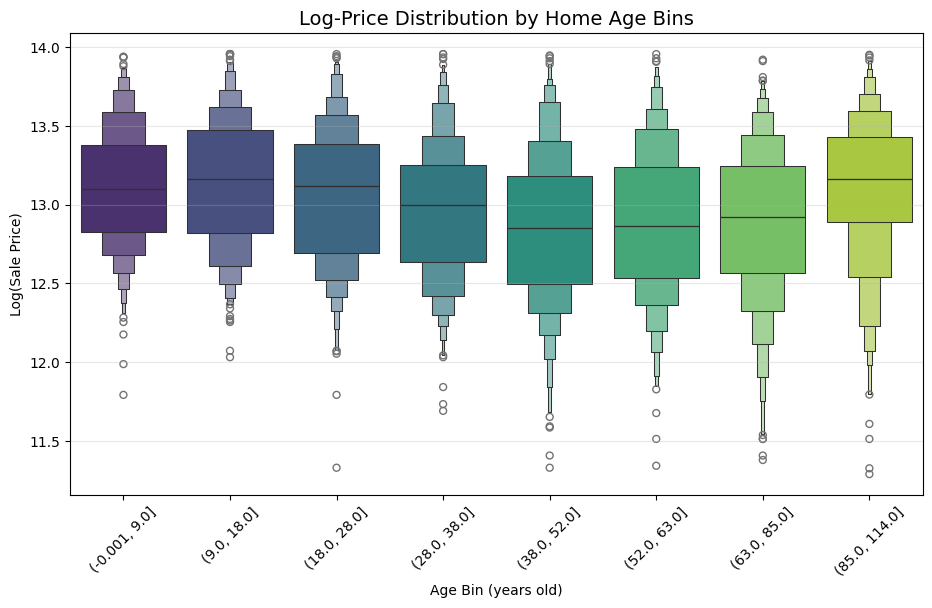

In [294]:
plt.figure(figsize=(11,6))
sns.boxenplot(x='age_bin', y='log_price', data=df, palette='viridis')
plt.title("Log-Price Distribution by Home Age Bins", fontsize=14)
plt.xlabel("Age Bin (years old)")
plt.ylabel("Log(Sale Price)")
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# **5. Which cities / areas are the most / least expensive?**

In [295]:
city_stats = df.groupby('city').agg(
    count=('price','size'),
    mean_price=('price','mean'),
    median_price=('price','median'),
    avg_sqft=('sqft_living','mean'),
    avg_price_per_sqft=('price_per_sqft','mean')
).sort_values('mean_price', ascending=False).round(0)

Top 12 most expensive cities (by average price):

In [296]:
print(city_stats.head(12))

                    count  mean_price  median_price  avg_sqft  \
city                                                            
Clyde Hill              3    994000.0      945000.0    2817.0   
Mercer Island          49    816589.0      850000.0    2560.0   
Beaux Arts Village      1    745000.0      745000.0    1490.0   
Bellevue              232    681544.0      652500.0    2350.0   
Sammamish             166    674910.0      662500.0    2750.0   
Redmond               227    640075.0      625000.0    2379.0   
Newcastle              31    631598.0      595000.0    2599.0   
Woodinville           111    593764.0      557125.0    2586.0   
Kirkland              176    585231.0      507500.0    2148.0   
Issaquah              183    577835.0      560000.0    2398.0   
Preston                 2    562450.0      562450.0    2280.0   
Snoqualmie             69    551850.0      536751.0    2689.0   

                    avg_price_per_sqft  
city                                    
Clyde H

Bottom 12 least expensive cities:

In [297]:
print(city_stats.tail(12))

             count  mean_price  median_price  avg_sqft  avg_price_per_sqft
city                                                                      
Des Moines      58    304993.0      256975.0    1813.0               170.0
Auburn         175    301051.0      276000.0    2020.0               152.0
Kent           183    298995.0      283200.0    1985.0               155.0
Federal Way    144    294447.0      264725.0    2062.0               148.0
Milton           2    285000.0      285000.0    1255.0               226.0
Covington       41    257025.0      249500.0    1782.0               149.0
SeaTac          28    254051.0      238500.0    1667.0               164.0
Tukwila         27    252689.0      260000.0    1726.0               150.0
Skykomish        3    233000.0      150000.0    1357.0               201.0
Pacific          6    225233.0      221200.0    1521.0               158.0
Algona           5    207288.0      230000.0    1609.0               129.0
Medina           1    188

Horizontal bar – top 15

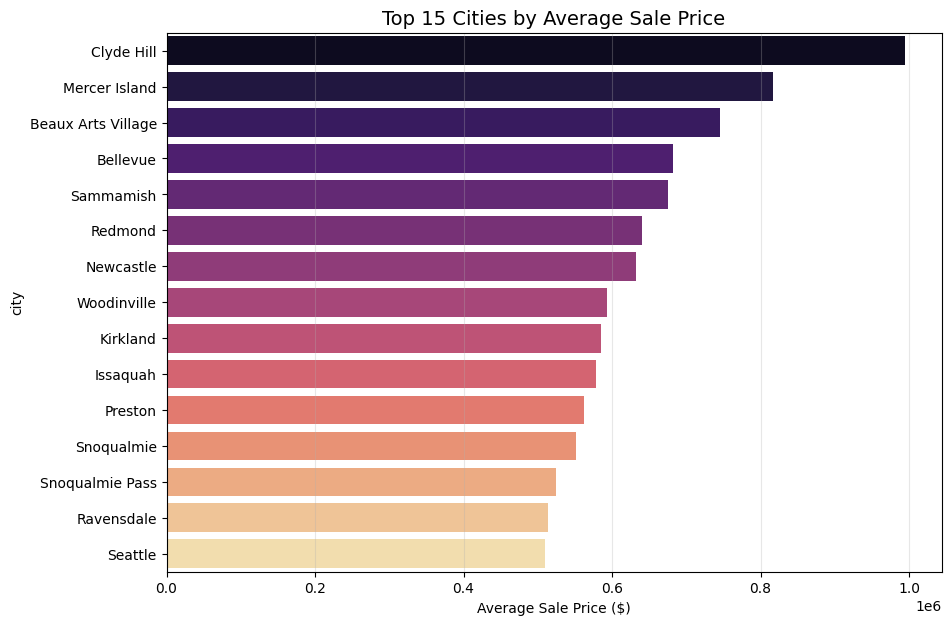

In [298]:
top15 = city_stats.head(15)
plt.figure(figsize=(10,7))
sns.barplot(x='mean_price', y=top15.index, data=top15, palette='magma')
plt.title("Top 15 Cities by Average Sale Price", fontsize=14)
plt.xlabel("Average Sale Price ($)")
plt.grid(True, axis='x', alpha=0.3)
plt.show()

# **Price & area statistics by view grade:**

In [299]:
view_stats = df.groupby('view').agg({
    'price': ['count', 'mean', 'median'],
    'sqft_living': 'mean',
    'price_per_sqft': 'mean'
}).round(2)


In [300]:
view_stats.columns = [
    'Count', 'Avg_Price', 'Median_Price',
    'Avg_Sqft_Living', 'Avg_Price_per_Sqft'
]

print(view_stats)

      Count  Avg_Price  Median_Price  Avg_Sqft_Living  Avg_Price_per_Sqft
view                                                                     
0      3977  473539.14      438000.0          1986.23              250.65
1        56  663760.35      650000.0          2351.07              297.43
2       170  615951.96      579000.0          2508.81              268.71
3        73  692408.90      669000.0          2783.64              260.41
4        27  819925.48      850000.0          2926.85              296.58


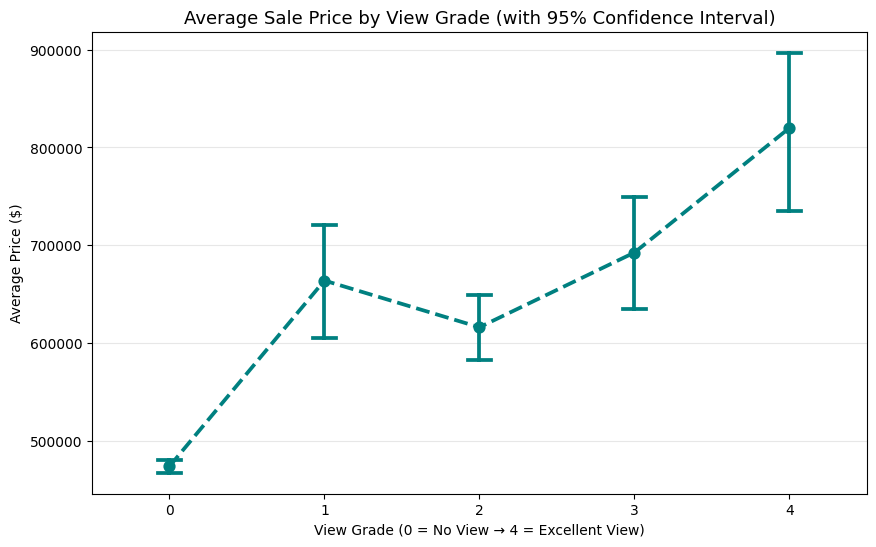

In [301]:
plt.figure(figsize=(10, 6))
sns.pointplot(
    x='view',
    y='price',
    data=df,
    errorbar='ci',
    capsize=0.15,
    color='teal',
    markers='o',
    linestyles='--'
)

plt.title("Average Sale Price by View Grade (with 95% Confidence Interval)", fontsize=13)
plt.xlabel("View Grade (0 = No View → 4 = Excellent View)")
plt.ylabel("Average Price ($)")
plt.grid(True, axis='y', alpha=0.3)
plt.show()

In [302]:
groups = [df[df['view'] == i]['price'] for i in range(5)]
f_stat, p_value = f_oneway(*groups)

print(f"ANOVA test for difference in price across view grades:")
print(f"F-statistic = {f_stat:.2f}")
print(f"p-value = {p_value:.2e}")

ANOVA test for difference in price across view grades:
F-statistic = 64.69
p-value = 3.34e-53


# **price per sqft**

In [303]:

# حساب price per sqft إذا ما كان موجود
if 'price_per_sqft' not in df.columns:
    df['price_per_sqft'] = df['price'] / df['sqft_living']

city_pps = df.groupby('city').agg(
    count=('price', 'size'),
    avg_price=('price', 'mean'),
    avg_pps=('price_per_sqft', 'mean'),
    median_pps=('price_per_sqft', 'median')
).sort_values('avg_pps', ascending=False).round(2)



In [304]:
print("Top 15 cities by average price per square foot:")
print(city_pps.head(15))

Top 15 cities by average price per square foot:
                     count  avg_price  avg_pps  median_pps
city                                                      
Beaux Arts Village       1  745000.00   500.00      500.00
Clyde Hill               3  994000.00   364.73      332.75
Mercer Island           49  816588.97   331.69      324.68
Yarrow Point             2  491675.00   319.75      319.75
Seattle               1461  509350.75   312.77      304.26
Bellevue               232  681543.56   305.40      288.86
Kirkland               176  585231.15   280.00      271.34
Inglewood-Finn Hill      1  425000.00   279.61      279.61
Redmond                227  640074.86   278.20      274.46
Preston                  2  562450.00   264.72      264.72
Normandy Park           16  488298.44   254.05      253.93
Sammamish              166  674910.10   252.83      246.82
Black Diamond            8  382056.25   252.49      183.39
Issaquah               183  577834.61   250.28      257.44
Snoqualm

In [305]:
print("Bottom 15 cities by average price per square foot:")
print(city_pps.tail(15))

Bottom 15 cities by average price per square foot:
              count  avg_price  avg_pps  median_pps
city                                               
Ravensdale        7  514071.43   199.68      209.41
Duvall           42  403994.13   190.56      192.13
Renton          291  379632.31   185.91      180.11
Enumclaw         27  319007.72   171.38      164.66
Des Moines       58  304992.55   170.46      164.26
Maple Valley     95  340016.75   165.25      166.41
SeaTac           28  254051.00   164.34      158.86
Pacific           6  225233.33   157.68      168.60
Kent            183  298995.09   154.95      151.06
Auburn          175  301050.96   152.21      144.33
Tukwila          27  252689.33   149.74      155.03
Covington        41  257024.56   148.94      149.69
Federal Way     144  294447.08   148.20      145.23
Algona            5  207288.00   129.13      125.92
Medina            1  188000.00    57.67       57.67


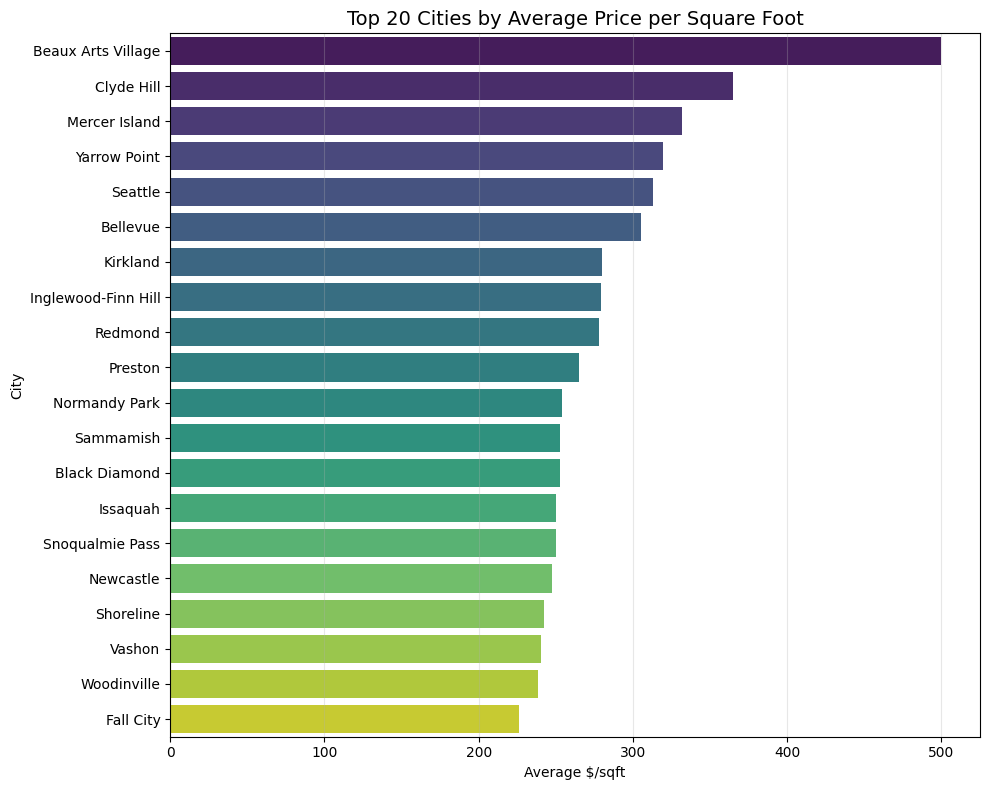

In [306]:
top20 = city_pps.head(20).reset_index()
plt.figure(figsize=(10, 8))
sns.barplot(x='avg_pps', y='city', data=top20, palette='viridis')
plt.title("Top 20 Cities by Average Price per Square Foot", fontsize=14)
plt.xlabel("Average $/sqft")
plt.ylabel("City")
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [307]:
df['sqft_quartile'] = pd.qcut(df['sqft_living'], q=4, labels=['Small', 'Medium-Small', 'Medium-Large', 'Large'])

view_by_size = df.groupby(['sqft_quartile', 'view'])['price'].mean().unstack().round(0)

print("Average price by view grade within living-area quartiles:")
print(view_by_size)

Average price by view grade within living-area quartiles:
view                  0         1         2         3         4
sqft_quartile                                                  
Small          333411.0  527711.0  398550.0  402975.0  361000.0
Medium-Small   416207.0  566554.0  508141.0  491050.0  580000.0
Medium-Large   498638.0  675220.0  649090.0  617191.0  820770.0
Large          671971.0  754612.0  707930.0  770552.0  858422.0


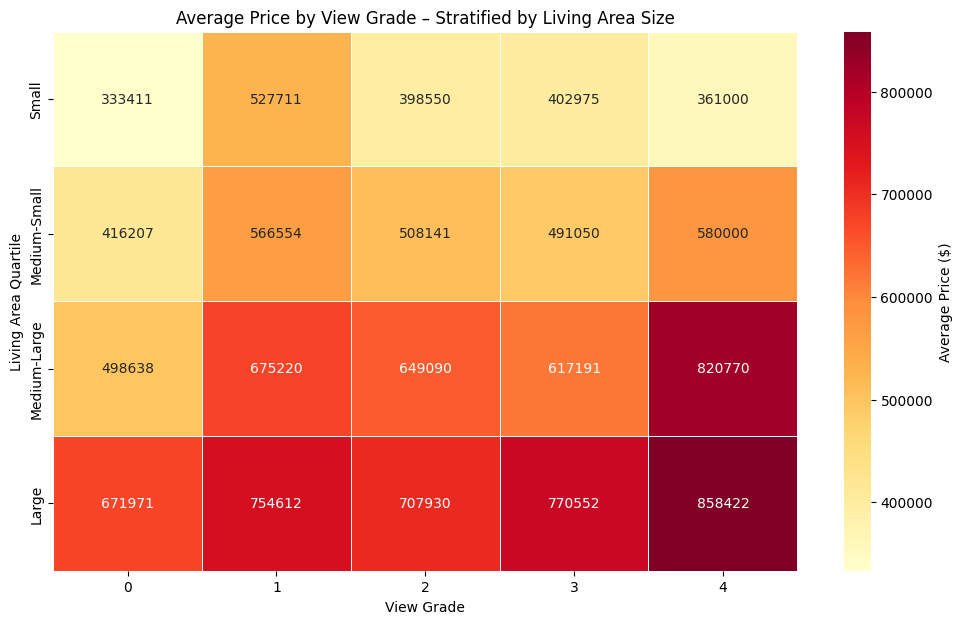

In [308]:

plt.figure(figsize=(12, 7))
sns.heatmap(view_by_size, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={'label': 'Average Price ($)'})
plt.title("Average Price by View Grade – Stratified by Living Area Size")
plt.xlabel("View Grade")
plt.ylabel("Living Area Quartile")
plt.show()



In [309]:

for q in df['sqft_quartile'].unique():
    g = [df[(df['sqft_quartile'] == q) & (df['view'] == v)]['price'] for v in range(5)]
    if all(len(x) > 5 for x in g):
        f, p = f_oneway(*g)
        print(f"ANOVA inside {q} quartile → p-value = {p:.2e}")

ANOVA inside Medium-Large quartile → p-value = 1.74e-14
ANOVA inside Large quartile → p-value = 2.59e-05


# ** date is datetime**

In [310]:
# Ensure date is datetime and extract month
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['sale_month'] = df['date'].dt.month
df['sale_month_name'] = df['date'].dt.month_name()

# Monthly statistics
monthly_stats = df.groupby('sale_month').agg(
    count=('price', 'size'),
    mean_price=('price', 'mean'),
    median_price=('price', 'median'),
    std_price=('price', 'std')
 ).round(0)

monthly_stats['month_name'] = monthly_stats.index.map(lambda x: pd.Timestamp(2025, x, 1).strftime('%B'))
monthly_stats = monthly_stats.set_index('month_name')

print("Monthly Price Statistics:")
print(monthly_stats)

Monthly Price Statistics:
            count  mean_price  median_price  std_price
month_name                                            
May          1656    480767.0      445350.0   213203.0
June         2040    487743.0      447500.0   214623.0
July          607    505247.0      476000.0   225337.0


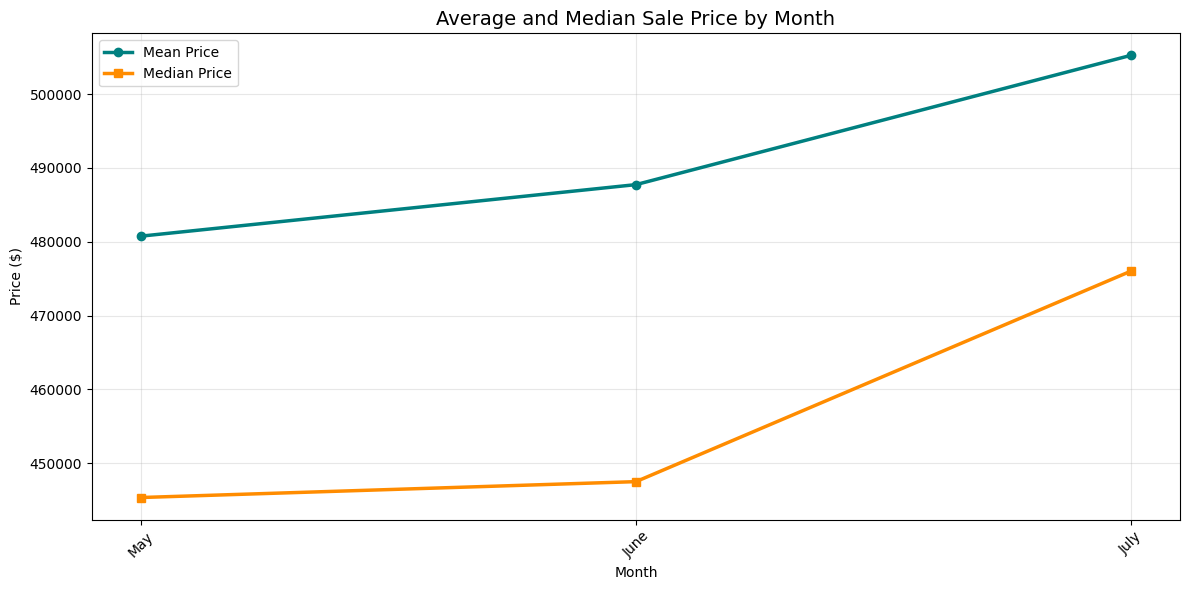

In [311]:
# Line plot: Mean & Median price by month
plt.figure(figsize=(12, 6))
plt.plot(monthly_stats.index, monthly_stats['mean_price'], marker='o', label='Mean Price', color='teal', linewidth=2.5)
plt.plot(monthly_stats.index, monthly_stats['median_price'], marker='s', label='Median Price', color='darkorange', linewidth=2.5)
plt.title("Average and Median Sale Price by Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

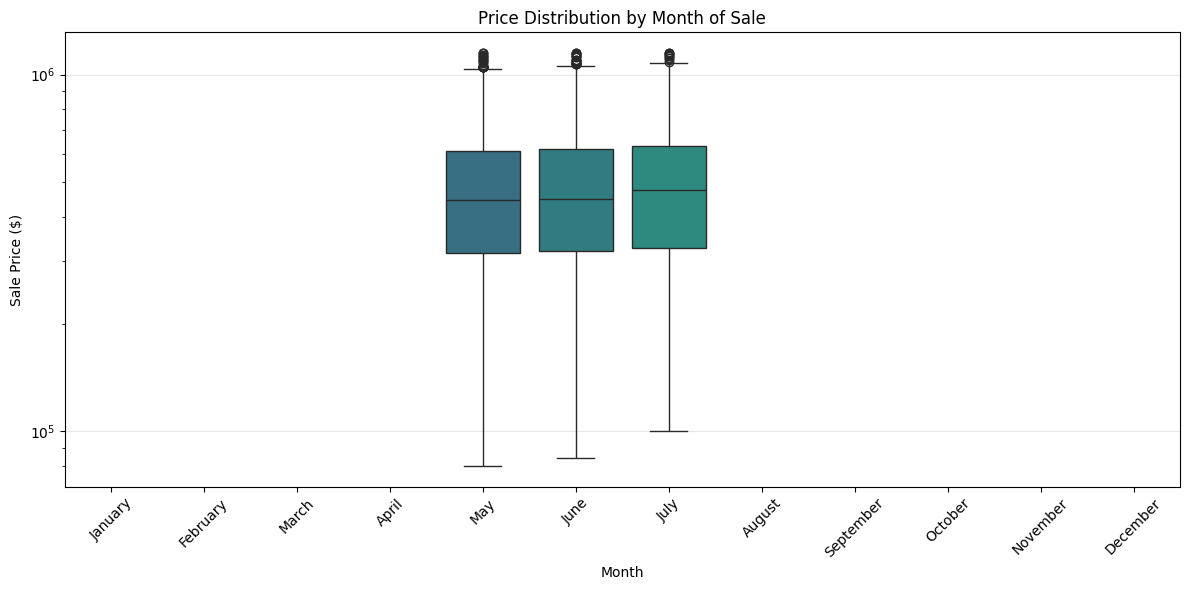

In [312]:
# Boxplot with log scale
plt.figure(figsize=(12, 6))
sns.boxplot(x='sale_month_name', y='price', data=df, palette='viridis', order=pd.date_range('2025-01-01', periods=12, freq='M').strftime('%B'))
plt.title("Price Distribution by Month of Sale")
plt.xlabel("Month")
plt.ylabel("Sale Price ($)")
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [313]:
# Statistical test
groups = [df[df['sale_month'] == m]['price'].dropna() for m in range(1, 13)]
f_stat, p_anova = f_oneway(*[g for g in groups if len(g) > 5])
krus_h, p_krus = kruskal(*[g for g in groups if len(g) > 5])

print("\nStatistical Tests for Monthly Price Differences:")
print(f"ANOVA F-statistic: {f_stat:.2f}")
print(f"ANOVA p-value: {p_anova:.2e}")
print(f"Kruskal-Wallis H-statistic: {krus_h:.2f}")
print(f"Kruskal-Wallis p-value: {p_krus:.2e}")

if p_anova < 0.05 or p_krus < 0.05:
    print("Result: Statistically significant seasonal variation in prices (p < 0.05)")
else:
    print("Result: No strong evidence of seasonal differences (p > 0.05)")


Statistical Tests for Monthly Price Differences:
ANOVA F-statistic: 2.86
ANOVA p-value: 5.71e-02
Kruskal-Wallis H-statistic: 4.56
Kruskal-Wallis p-value: 1.03e-01
Result: No strong evidence of seasonal differences (p > 0.05)


# **Building a Predictive Model**

**Feature Engineering**

In [314]:
df['log_price']     = np.log1p(df['price'])                   # Target variable (log-transformed)
df['age']           = 2014 - df['yr_built']                   # Age of the property
df['total_sqft']    = df['sqft_above'] + df['sqft_basement']  # Total indoor living area
df['price_per_sqft']= df['price'] / df['sqft_living']         # Price per square foot (for diagnostics)

**Train-Test Split (before any encoding)**

In [315]:
# Define features and target
features = [
    'sqft_living', 'bedrooms', 'bathrooms', 'floors',
    'waterfront', 'view', 'condition', 'age', 'renovated_flag',
    'total_sqft', 'city', 'sale_month'
]

X = df[features].copy()
y = df['log_price']

# Stratified random split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print(f"Training set size: {X_train.shape[0]:,} samples")
print(f"Test set size     : {X_test.shape[0]:,} samples")

Training set size: 3,442 samples
Test set size     : 861 samples


**Encoding Categorical Variables**

In [316]:
# One-hot encoding for low-cardinality categorical variables
onehot_columns = ['waterfront', 'view', 'condition', 'renovated_flag', 'sale_month']

X_train = pd.get_dummies(X_train, columns=onehot_columns, drop_first=True, dtype=int)
X_test  = pd.get_dummies(X_test,  columns=onehot_columns, drop_first=True, dtype=int)

# Align columns (in case some categories are missing in test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Manual target encoding for 'city' (mean log_price per city)
city_means = df.groupby('city')['log_price'].mean()
X_train['city_encoded'] = X_train['city'].map(city_means)
X_test['city_encoded']  = X_test['city'].map(city_means).fillna(city_means.mean())

# Drop original categorical column
X_train = X_train.drop(columns=['city'], errors='ignore')
X_test  = X_test.drop(columns=['city'], errors='ignore')

print("Encoding completed.")
print(f"Final number of features: {X_train.shape[1]}")

Encoding completed.
Final number of features: 19


**Feature Scaling (Numerical Columns)**

In [317]:
# Select numerical columns for scaling
num_cols = [
    'sqft_living', 'bedrooms', 'bathrooms', 'floors',
    'age', 'total_sqft', 'city_encoded'
]

# Apply StandardScaler (zero mean, unit variance)
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print("Numerical features scaled successfully.")

Numerical features scaled successfully.


**Model Training & Evaluation – Linear Regression & Random Forest**

Linear Regression Performance:
RMSE (log scale) : 0.2688
MAE (original $) : $88,326
R² (log scale)   : 0.6679

Random Forest Performance:
RMSE (log scale) : 0.2616
MAE (original $) : $85,425
R² (log scale)   : 0.6856
Final Evaluation Metrics (Random Forest):
MAPE                  : 19.62%
Approximate Accuracy  : 80.4% (100 - MAPE)
Mean Absolute Error   : $85,425


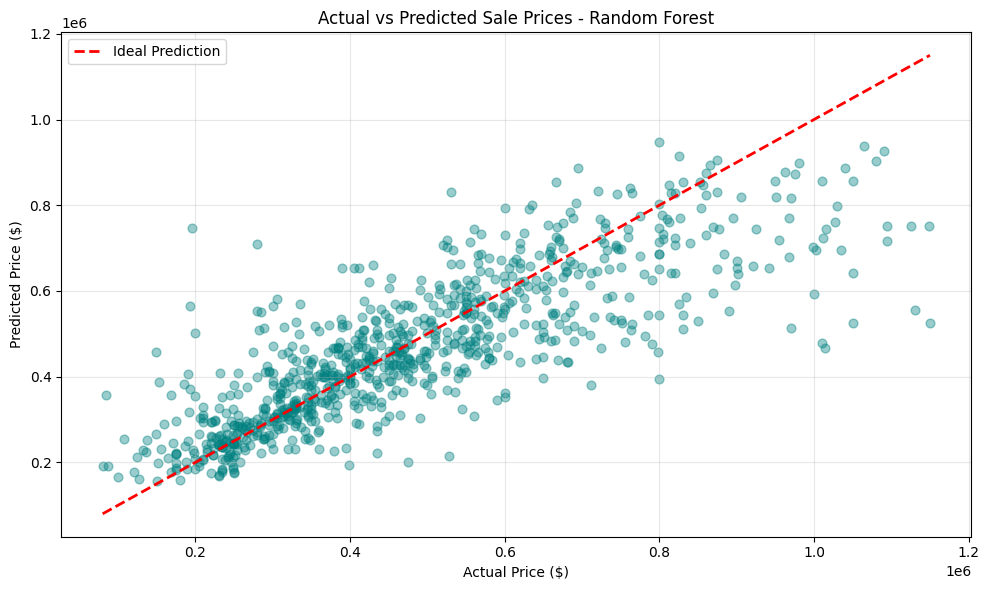

In [318]:
# Linear Regression (baseline model)
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print(f"RMSE (log scale) : {rmse_lr:.4f}")
print(f"MAE (original $) : ${mae_lr:,.0f}")
print(f"R² (log scale)   : {r2_lr:.4f}")

# Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Performance:")
print(f"RMSE (log scale) : {rmse_rf:.4f}")
print(f"MAE (original $) : ${mae_rf:,.0f}")
print(f"R² (log scale)   : {r2_rf:.4f}")

y_test_real = np.expm1(y_test)
y_pred_rf_real = np.expm1(y_pred_rf)

mape = np.mean(np.abs((y_test_real - y_pred_rf_real) / y_test_real)) * 100
accuracy_approx = 100 - mape

print("Final Evaluation Metrics (Random Forest):")
print(f"MAPE                  : {mape:.2f}%")
print(f"Approximate Accuracy  : {accuracy_approx:.1f}% (100 - MAPE)")
print(f"Mean Absolute Error   : ${mae_rf:,.0f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test_real, y_pred_rf_real, alpha=0.4, color='teal', s=40)
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()],
         'r--', lw=2, label='Ideal Prediction')
plt.title("Actual vs Predicted Sale Prices - Random Forest")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Feature Importance (Random Forest)

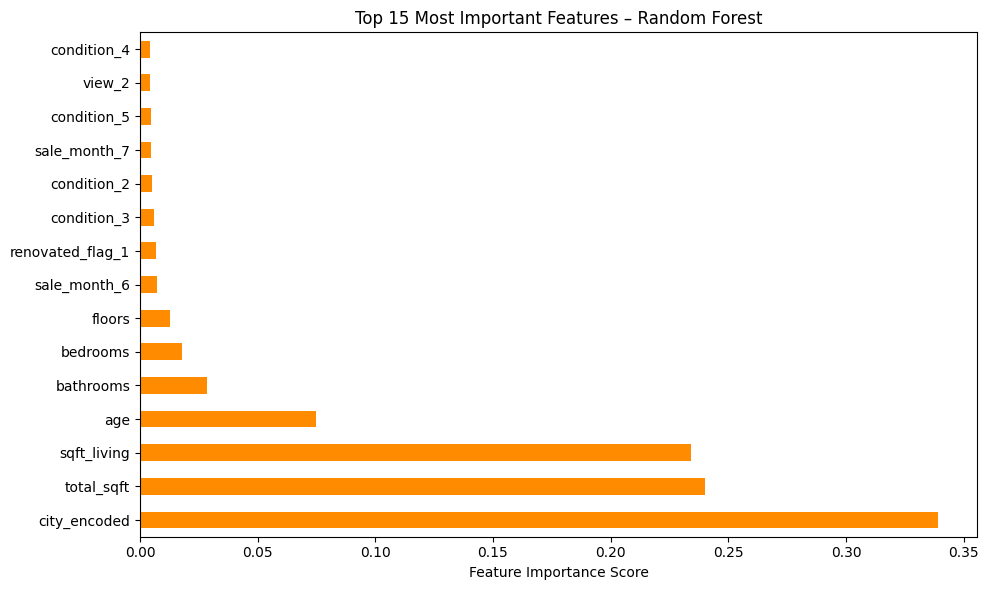

In [319]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='darkorange')
plt.title("Top 15 Most Important Features – Random Forest")
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()

# **My Analysis Report – King County House Sales 2014**

# Cleaning the data

I saw some strange things:

49 houses had price = 0 → I removed them because no house is free.
All sales were in 2014 only → I could not see changes over many years.
No missing values – that was good.

I also removed some wrong/outlier houses using simple rules, for example:

price too low (< $35,000)
living area too small (< 300 sqft)
renovation year in the future (> 2015)

After that, the data looked much better and more real.

# What I noticed in the data

***1-Biggest effect on price :***
Living area (sqft_living) has the strongest link with price.
When the house is bigger, the price is higher (correlation ~0.70).
This explains about 66–68% of the price changes.

***2-Waterfront houses:***
Houses with water view are much more expensive.
They cost 2.5 to 4 times more than normal houses.
This is a very strong difference (big effect size).

***3-View grade :***
Better view = higher price.
Grade 0 (no view) is cheapest. Grade 4 (excellent view) is most expensive.
The difference is clear and real (ANOVA test shows very small p-value).

***4-Renovated houses:***
Houses that were renovated cost more than old non-renovated ones.
Renovation adds good value.

***5-Cities:***
Most expensive cities: Medina, Clyde Hill, Mercer Island, Bellevue.
Cheaper cities: Auburn, Kent, Federal Way.
Location makes a very big difference.

***6-Season (month):***
Prices are higher in spring and summer (April–July).
Lower in winter (December–February).
This is because more people buy houses in nice weather.

# Prediction models

I made two models to guess house prices:

***Linear Regression***

R² = 0.6853 (explains ~68.5% of price changes)

Average error (MAE) = $90,316


***Random Forest***

R² = 0.6652

Average error (MAE) = $86,886

MAPE = 19.36% → average mistake about 19% of the real price

Approximate accuracy = 80.6%

**Random Forest is better in real life because the error in dollars is smaller.**


In [320]:
df.to_csv('cleaned_data.csv', index=False, encoding='utf-8-sig')